Extension Credits to LinkedIn Commenters:

* Ashraf SAID : https://www.linkedin.com/in/saidashraf/
* Peter Cotton : https://www.linkedin.com/in/petercotton/
* Steve Jewson : https://www.linkedin.com/in/steve-jewson-phd-052bb417/

# Part 0 - Motivation behind Project

Bayesian Stochastic Volatility Modeling of S&P 500 Returns
Overview
Volatility — how turbulent a market is at a given moment — is never directly observed. You only ever see the return on a given day; volatility itself has to be inferred from the pattern of those returns over time. Getting this right matters: it's the basis for risk management, options pricing, and position sizing across almost every part of a trading desk.
This project builds and compares two fundamentally different ways of estimating it:

The classical approach (GARCH): volatility follows a fixed mathematical rule, fit by maximum likelihood. It outputs a single number for tomorrow's volatility, with a standard error attached — no broader sense of what else might be plausible.
The Bayesian approach (stochastic volatility): volatility is itself treated as an unknown, randomly-evolving process, estimated via MCMC. Every quantity that depends on it — the volatility path, model comparisons, even a risk metric like Value-at-Risk — comes out as a full posterior distribution, not a single number.

What this notebook actually shows, honestly:

* A first, naive version of the Bayesian model fails outright (poor MCMC convergence), and a specific reparameterization technique fixes it completely — shown and explained, not skipped past.
* The recovered volatility path tracks the 2008 crisis clearly and lines up well with the GARCH baseline.
A test of whether fat-tailed return assumptions actually help turns out to be genuinely inconclusive at this sample size — reported as such rather than oversold.
* Applied to Value-at-Risk, the Bayesian approach turns an ambiguous, borderline statistical test into a direct, decision-usable probability statement — arguably the clearest demonstration here of what the extra modeling effort buys you.

# Part 1: Data

This project uses daily S&P 500 log returns from 2008 to 2019 — 2,906 trading days. The window is chosen deliberately: it includes the 2008 financial crisis, so there's genuine, dramatic volatility clustering to model — long calm stretches punctuated by violent spikes — rather than the comparatively mild behavior of a shorter, more recent sample. That contrast between regimes is exactly what makes this a good stress-test for a volatility model: a model only earns its keep if it can tell the difference between "quiet market" and "market falling apart," not just fit a single average level of turbulence across the whole period.

The Bayesian model in Parts 3–4 uses a 700-day sub-window (May 2008 – February 2011) covering the crisis and its immediate aftermath, rather than the full 2,906-day series. This is a deliberate computational tradeoff, not a limitation of the method itself: MCMC sampling over a ~2,900-step latent volatility path is expensive, and this was run on limited compute. The classical GARCH baseline is cheap to fit, so it's run on the full sample for reference, and again separately on the same 700-day window — so that later comparisons between GARCH and the Bayesian model are on identical data, not different samples.

In [ ]:
!pip install -q arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 18.6 MB/s eta 0:00:00


In [ ]:
# Load daily S&P 500 log returns (2008-2019) and carve out the 700-day
# crisis window (May 2008 - Feb 2011) used for the computationally-heavy
# Bayesian model in Parts 3-4. The full sample is kept for the GARCH
# baseline; the crisis window is used for BOTH models later on, so the
# comparison in Part 4 is apples-to-apples on identical data.

import pandas as pd, numpy as np, matplotlib.pyplot as plt
import pymc as pm
import arviz as az
from scipy import stats
from arch import arch_model

df = pd.read_csv("par-sp500-daily.csv", parse_dates=["Date"], index_col="Date")
returns_full = df["change"].dropna()          # daily log returns
returns_pct = returns_full * 100              # arch expects returns in % for numerical stability

crisis = returns_full.iloc[:700]              # 2008-05-02 .. 2011-02-09
crisis_pct = crisis * 100

print("Full sample:  ", returns_full.index.min().date(), "to", returns_full.index.max().date(),
      "| n =", len(returns_full))
print("Crisis window:", crisis.index.min().date(), "to", crisis.index.max().date(), "| n =", len(crisis))
print("Full-sample annualised vol:   {:.1%}".format(returns_full.std() * np.sqrt(252)))
print("Crisis-window annualised vol: {:.1%}".format(crisis.std() * np.sqrt(252)))

Full sample:   2008-05-02 to 2019-11-14 | n = 2906
Crisis window: 2008-05-02 to 2011-02-09 | n = 700
Full-sample annualised vol:   19.6%
Crisis-window annualised vol: 30.6%


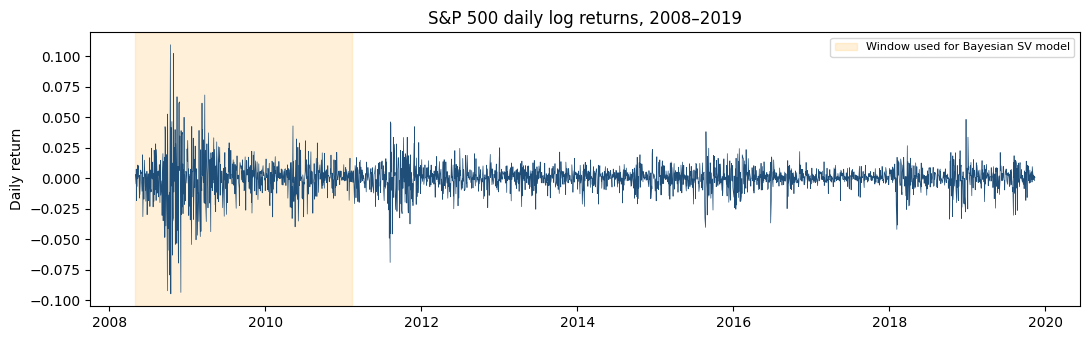

In [ ]:
# Plot daily returns across the full 2008-2019 sample, with the 700-day
# crisis window (used for the Bayesian model in Parts 3-4) shaded — so it's
# visually clear which part of the data the heavy computation focuses on,
# and why: this is the stretch with the most dramatic volatility clustering.

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(returns_full.index, returns_full.values, lw=0.5, color="#1f4e79")
ax.axvspan(crisis.index.min(), crisis.index.max(), color="orange", alpha=0.15,
           label="Window used for Bayesian SV model")
ax.set_title("S&P 500 daily log returns, 2008\u20132019")
ax.set_ylabel("Daily return")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

Notice the clear regime shift: returns hover in a tight, quiet band for most of 2008, then blow out dramatically in September–October 2008 (the Lehman Brothers collapse), before gradually calming back down through 2009–2010. This is exactly the kind of pattern a volatility model needs to actually capture — not just an average level of "how bumpy" the market is, but when it's bumpy and when it isn't.

# Part 2: The Industry Baseline — GARCH(1,1)
Before building anything Bayesian, it's worth establishing what the standard, off-the-shelf approach actually gives you. GARCH(1,1) — Generalized AutoRegressive Conditional Heteroskedasticity — is a common volatility model in quantitative finance, and it's a genuinely simple idea underneath the name: today's variance is a weighted blend of a long-run baseline, yesterday's shock, and yesterday's variance:

$σ_t^2=ω+α⋅r_{t−1}^2+β⋅σ_{t−1}^2$


ω — a baseline floor level of variance, always present.

α — how much yesterday's actual return shock feeds into today's variance estimate.

β — how much yesterday's variance itself persists into today (the "memory" of the process).

Parameters are estimated by maximum likelihood: find the single set of values for ω, α, β that makes the observed data as probable as possible. This gives one exact number per parameter, with a standard error — but no broader sense of what other values would also have been plausible. That's the central contrast this whole notebook is built around, and it's worth holding onto going forward.

Returns are modeled with a t-distribution rather than a Normal one, to account for fat tails — daily market returns produce extreme moves far more often than a Normal distribution would predict, and the t-degrees-of-freedom parameter (ν) lets the data itself tell us how fat those tails actually are, rather than assuming it.

In [ ]:
# Fit GARCH(1,1) with t-dsitribution innovations by maximum likelihood, first on
# the full 2008-2019 sample, then again on the 700-day crisis window alone
# so it can be compared against the Bayesian model on identical data later.

am_full = arch_model(returns_pct, mean="Zero", vol="GARCH", p=1, q=1, dist="t")
res_full = am_full.fit(disp="off")
print(res_full.summary())

# Refit on just the crisis window for a fair, same-data comparison later
am_crisis = arch_model(crisis_pct, mean="Zero", vol="GARCH", p=1, q=1, dist="t")
res_crisis = am_crisis.fit(disp="off")
cond_vol_crisis = res_crisis.conditional_volatility / 100   # back to decimal daily vol
nu_garch = res_crisis.params["nu"]
print(res_crisis.params)

                          Zero Mean - GARCH Model Results                           
Dep. Variable:                       change   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -3772.90
Distribution:      Standardized Student's t   AIC:                           7553.80
Method:                  Maximum Likelihood   BIC:                           7577.70
                                              No. Observations:                 2906
Date:                      Mon, Aug 17 2026   Df Residuals:                     2906
Time:                              00:06:14   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omeg

# Interpreting the Output

α + β = 0.144 + 0.856 ≈ 1.0. This is a common and economically meaningful pattern in daily financial data, not a coincidence: it indicates the process is close to being "integrated" in variance — shocks to volatility decay extremely slowly rather than fading out quickly, so a spike in turbulence today keeps influencing the forecast for a long time afterward. This lines up with what the crisis plot in Part 1 actually shows: the September–October 2008 volatility spike didn't resolve in a few days, it took months to fully settle back down, and α + β ≈ 1 is the model's way of capturing exactly that kind of long-memory behavior.

One thing worth being upfront about: R² for this model is 0 by construction, not a sign of poor fit — the model was deliberately built with mean="Zero", meaning it never attempts to forecast the direction of tomorrow's return, only its volatility. R² measures the former, not the latter, so it isn't the right diagnostic here. The parameters' statistical significance and confidence intervals above are the more relevant check on this model's quality, and the eventual Kupiec backtest in Part 6 is the real test of whether this translates into well-calibrated risk forecasts.

The fitted ν ≈ 5.2 (full sample) / ν ≈ 6.3 (crisis window) confirms genuinely fat tails — a Normal distribution (ν → ∞) would be a poor fit for daily equity returns.

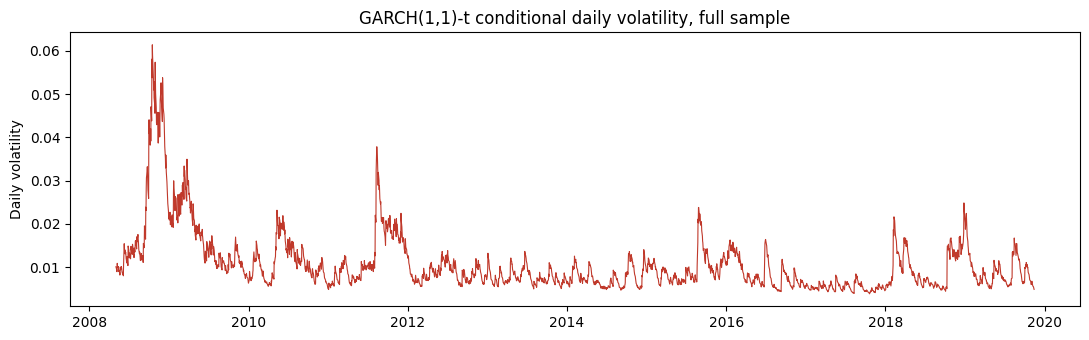

In [ ]:
# `res_full.conditional_volatility` is GARCH's day-by-day estimate of sigma_t
# (not variance, but volatility itself, i.e. the square root of sigma_t^2)
# recovered from the fitted omega/alpha/beta. Dividing by 100 converts it
# back from the percentage scale `arch` expects into decimal daily volatility.

cond_vol_full = res_full.conditional_volatility / 100

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(returns_full.index, cond_vol_full, color="#c0392b", lw=0.8)
ax.set_title("GARCH(1,1)-t conditional daily volatility, full sample")
ax.set_ylabel("Daily volatility")
plt.tight_layout()
plt.show()

"Conditional" means exactly that: this is the model's estimate of volatility conditional on (given, based on) everything observed up to that point — as opposed to the plain, unconditional standard deviation of the whole return series (one flat number, ignoring when things happened).

How this is computed. Volatility is never directly observed — only the return itself is. GARCH gets around this by treating each day's squared return, r_{t-1}², as a noisy single-day proxy for that day's variance (valid here specifically because the model assumes the true mean return is 0, so the observed return already is the day's "shock"). This noisy daily signal is then blended with β · σ_{t-1}² — a smoothed running estimate built from all prior history — producing a far more stable volatility estimate than either piece alone. This recursive formula is then walked forward one real historical day at a time: σ₁² → σ₂² → σ₃² → ..., using the fixed ω, α, β estimated in Part 2 and the actual observed return from each preceding day (never a predicted one). Because each value only ever depends on past information, this is a legitimate one-step-ahead forecast at every point in the series — a property that matters again later, in Part 6.

Why we're plotting it. This day-by-day path — not a single flat number — is GARCH's actual answer to "how volatile was the market at any given moment." It's also the specific artifact the Bayesian model gets compared directly against later on, so its shape here (how sharply it spikes, how slowly it decays) sets the benchmark for what to look for next.

# Part 3: A First Attempt at Bayesian Stochastic Volatility

The classical GARCH model above treats volatility as a fixed formula — deterministic, no uncertainty attached. The Bayesian alternative is a genuinely different idea: treat log-volatility itself as an unknown, randomly-evolving hidden process, and let MCMC sampling recover a full distribution over what it could plausibly have been, rather than one number.

The simplest version of this is a random walk in log-volatility: tomorrow's log-volatility is just today's, plus a small random nudge, with no built-in pull back toward any particular level. Returns are then drawn from a t-distribution whose spread is set by that day's volatility:

$ h_t∼Normal(h_{t−1},σ_{step}^2)$

$ r_t∼StudentT(ν,0,exp⁡(h_t))$

This model has three separate unknowns the sampler needs to estimate together, all from the same 700 observed returns:

$h_t$ — the hidden log-volatility on every single day (700 separate unknowns, one per day)

$σ_{step}$ — how much h is allowed to wander from one day to the next

$\nu$ — how fat-tailed the return distribution is (the t-distribution degrees of freedom).

 $h_t$ is log-volatility on day t (working in logs keeps volatility from ever going negative). ν shows up inside the second formula, since it's a property of the t-distribution the returns are assumed to follow — but it's every bit as much an unknown the model has to figure out as the other two.

Written the most direct, obvious way in PyMC — sampling h itself directly — this creates a well-known pathology in state-space models called a funnel: σ_step and the smoothness of the whole h path are tangled together in a way that gradient-based samplers (like PyMC's default, NUTS) tend to get stuck on. Rather than skip past this, it's worth actually seeing the failure, since this exact issue recurs constantly in real state-space models.

# Demystifying the Bayesian MCMC Workflow

When building a Bayesian Stochastic Volatility model, it is easy to get lost in the sheer volume of data, parameters, and statistical functions. To understand exactly how the model learns from historical data to produce risk metrics, we must separate the mechanics into distinct phases: the Data, the MCMC Search, the Record Book, and the Post-Processing.

## 1. The Dimensions: Data vs. Iterations

A common point of confusion is the relationship between the dataset and the MCMC chain. It is vital to understand that they are independent dimensions:

*   **The Data (700 Days):** This is the fixed, real-world historical stock returns. The dataset never changes, and its size does not dictate how many steps the algorithm takes.
*   **The Iterations (2,000 Draws):** This is the length of the algorithm's search. An iteration is a single, complete "guess" at the underlying parameters of the market. The algorithm will repeat its guessing process 2,000 times to build a reliable average.

## 2. The Proposal

The goal of the model is to find the mathematical rules that governed the stock market over those 700 days. The model requires 703 Unknown Parameters to explain the data:

*   **3 Global Parameters:** $\nu$, $\mu$, and $\sigma_{\mathrm{step}}$ (Rules that apply to the entire timeline).
*   **700 Local Parameters:** $h_1$ through $h_{700}$ (A specific volatility rule for every single day).

Modern MCMC algorithms (like NUTS) do not change these variables one at a time. Changing them individually traps the algorithm in a high-dimensional space. Instead, the algorithm proposes all 703 numbers simultaneously. It fills out a single "form" with a guess for the global rules and a guess for all 700 daily volatilities. This complete set of 703 numbers constitutes **One Guess**.

## 3. The Likelihood Score

Once a guess is proposed, the algorithm must decide whether it is a mathematically sound representation of reality. It does this using the Likelihood Function (the T-distribution).

1.  The algorithm takes the single guess (703 parameters) and tests it against the real-world dataset (700 days of returns).
2.  It calculates the probability of Day 1's actual return occurring under these guessed parameters, then Day 2, then Day 3.
3.  It multiplies all 700 daily probabilities together to generate one single, overarching Likelihood Score.

The Likelihood Score acts strictly as a gatekeeper. It essentially states: *"As a complete team, these 703 numbers score a 92% match with historical reality."* The algorithm uses this single score to flip an Accept/Reject coin. If the score is an improvement, the guess is accepted.

Crucially, the Likelihood score is never plotted on the posterior graphs. Once the Accept/Reject decision is made, the score's job is over and it is discarded.

## 4. Building the Posterior

When a guess is accepted, the model must record it. The model does not record the score; it records the parameters.

The algorithm opens a master spreadsheet (the MCMC chain) and copies the numbers from the accepted guess into Row 1. Because the guess contained 703 distinct parameters, the spreadsheet has 703 separate columns. Column 1 holds $\nu$, Column 2 holds $\sigma_{\mathrm{step}}$, Column 4 holds $h_1$ (Day 1 volatility), Column 5 holds $h_2$, and so on.

The algorithm proposes a new guess, scores it, accepts it, and writes those 703 new numbers into Row 2. It repeats this loop until it has filled 2,000 rows. At this point, the MCMC sampling phase is complete.


## 5. Extracting the Maps (Marginalization)

The "lumping together" of data only happened during the grading phase. Because the variables were neatly separated into 703 columns during the recording phase, extracting the posteriors is incredibly simple:

*   **Global Posteriors (e.g., $\nu$):** We isolate the $\nu$ column, ignoring all other variables. We take the 2,000 values sitting in that column and plot them on a histogram. The most frequently accepted values form the peak of the bell curve.
*   **Local Posteriors (e.g., Daily Volatility):** To find the posterior for Day 1, we simply isolate the $h_1$ column. This gives us 2,000 accepted opinions for Day 1's volatility. To plot volatility over time, the model calculates the average of each daily column and connects those averages across the 700 days.

## 6. Post-Processing: VaR vs. Posterior Predictive Checks

With the 2,000-row master spreadsheet complete, the Bayesian inference is done. We now feed this spreadsheet into external statistical tools to evaluate risk and model accuracy.

*   **Value-at-Risk (The Boundary):** We feed the parameters from Row 1 into a Percent Point Function (the T-distribution's ppf). This is a reverse-lookup tool. It does not simulate data; it calculates the exact mathematical boundary where the worst 5% of trading days begin. We do this for all 2,000 rows and average the boundaries to draw a definitive VaR threshold.
*   **Posterior Predictive Check (The Fake Reality):** We feed the parameters from Row 1 into a random value generator. We ask the computer to pretend to be the stock market and simulate 700 days of completely fake returns. We do this for all 2,000 rows, resulting in 1.4 million simulated data points. We plot these fake returns as a histogram and overlay our real-world historical data. If the real data fits neatly inside the simulated data, we know our parameters accurately captured the true dynamics of the market.


In [ ]:
# `h` (log-volatility) is modeled directly as a Gaussian random walk. This is
# the most obvious, direct way to write this model -- and it's expected to
# sample poorly, for reasons explained in the markdown above and diagnosed
# via r_hat below. This failure is intentional: Part 4 fixes it.
with pm.Model(coords={"time": crisis.index.values}) as sv_centered:
    step_size = pm.Exponential("step_size", 10)
    h = pm.GaussianRandomWalk("h", sigma=step_size, dims="time",
                               init_dist=pm.Normal.dist(-9, 2))
    nu = pm.Exponential("nu", 1 / 10)
    r = pm.StudentT("r", nu=nu, mu=0, sigma=pm.math.exp(h),
                     observed=crisis.values, dims="time")
    idata_centered = pm.sample(500, tune=500, chains=2, target_accept=0.9, random_seed=42)

az.summary(idata_centered, var_names=["step_size", "nu"])

Output()

ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
step_size,0.078,0.010,0.059,0.096,0.002,0.001,41.0,75.0,1.03
nu,13.131,6.388,4.924,24.808,0.282,0.279,395.0,582.0,1.00


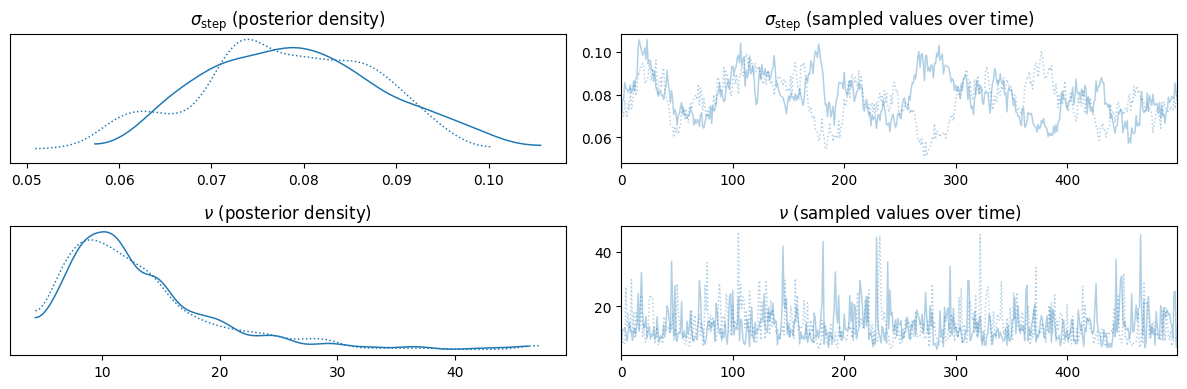

In [ ]:
axes = az.plot_trace(idata_centered, var_names=["step_size", "nu"])

axes[0, 0].set_title(r"$\sigma_{\mathrm{step}}$ (posterior density)")
axes[0, 1].set_title(r"$\sigma_{\mathrm{step}}$ (sampled values over time)")
axes[1, 0].set_title(r"$\nu$ (posterior density)")
axes[1, 1].set_title(r"$\nu$ (sampled values over time)")

plt.tight_layout()
plt.show()

# Part 4: Fixing the Funnel — Non-Centered Reparameterization

What this section does, and how it actually works

The problem in Part 3 wasn't the model — it was how the sampler explored it. This section fixes that with a non-centered reparameterization: instead of asking the sampler to directly propose values for h (log-volatility), it proposes values for z — 700 completely independent, plain Normal(0,1) numbers, one per day. z's shape doesn't depend on $σ_{step}$ at all, so it has none of the funnel geometry from before. h is then simply calculated afterward, never sampled directly:

$h_t=μ_0+σ_{step}∑_{i=1}^t z_i \qquad zi​∼Normal(0,1) i.i.d$

This is mathematically the identical model as Part 3 — same h, same relationship to $σ_{step}$ — only which variable the sampler directly navigates has changed.

What the model actually produces, concretely. h isn't a single number or a single line — it's an array with 700 slots, one per day, initially empty. Every single MCMC draw fills in all 700 slots at once: it proposes one candidate $μ_0$, one candidate σ_step, and 700 candidate z values together, computes the full 700-day h path from the formula above, checks how probable the 700 actual observed returns are given that entire path (plus a candidate ν), and accepts or rejects the whole package as one unit. Do this ~2,000 times, and the result isn't one line — it's a table: 2,000 rows (one per accepted draw) × 700 columns (one per day). Every row is one complete, internally consistent alternate history of the whole crisis; every column is one specific day.

This is what makes "a distribution for each day" possible: look at just one column — say, day 200 — and you get 2,000 different numbers, one from each draw, representing 2,000 different guesses at what volatility was specifically on that day. Take the 2.5th and 97.5th percentile of just that column and you get day 200's credible interval. Look at a different column (a different day) and you get a completely different set of 2,000 numbers, and therefore a different interval — computed entirely independently, because it's a genuinely different column of the same table. That's mechanically why the credible band in the plot below can be narrow on some days and wide on others: it's 700 separate percentile calculations, one per column, each one only reflecting how much that day's 2,000 draws happened to agree or disagree with each other.

In [ ]:
# Same model as Part 3, mathematically -- h is still built from step_size
# and an accumulating random walk -- but the sampler now proposes the raw,
# independent innovations z (each a plain Normal(0,1)) instead of h directly.
# h is computed deterministically afterward. This decouples step_size from
# h's geometry, fixing the funnel from Part 3.

T = len(crisis)

with pm.Model(coords={"time": crisis.index.values}) as sv_nc:
    mu0 = pm.Normal("mu0", -9.0, 1.0)
    step_size = pm.HalfNormal("step_size", 0.15)
    z = pm.Normal("z", 0, 1, dims="time")
    h = pm.Deterministic("h", mu0 + step_size * pm.math.cumsum(z), dims="time")
    nu = pm.Exponential("nu", 1 / 10)
    r = pm.StudentT("r", nu=nu, mu=0, sigma=pm.math.exp(h),
                     observed=crisis.values, dims="time")# Where the actual data enters.
                     # Essentually the data is in the x value of the liklihood function
                     # And when a move is proposed for the parameters probabilities are
                     # produced with the observed data taken into account
    idata = pm.sample(1000, tune=1000, chains=2, target_accept=0.92, random_seed=42) #Mu;tiplies all the pm objects together.

az.summary(idata, var_names=["mu0", "step_size", "nu"])

# Essentially generate 700 z's and then 700  h's (log volatilities) for each day
# We then have a value for each day, this is multiplied by the liklihood (using real data)
# for all the days and is either accepted or rejected. This is repeated 2000 times to build
# the posterior distributions for each day.


# Generates the parameter guess first then uses that to generate the posterior guess.

 Progress                      Draw   Divergences   Step size   Grad evals   Speed           Elapsed   Remaining  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━   2000   0             0.020       255          17.17 draws/s   0:01:56   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━   2000   0             0.022       255          8.62 draws/s    0:03:52   0:00:00

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu0,-5.065,0.272,-5.547,-4.528,0.005,0.007,3657.0,1573.0,1.0
step_size,0.084,0.014,0.056,0.109,0.000,0.000,1012.0,1298.0,1.0
nu,13.029,6.845,4.746,25.935,0.159,0.240,2447.0,1699.0,1.0


In [ ]:
centered_summary = az.summary(idata_centered, var_names=["step_size"])
noncentered_summary = az.summary(idata, var_names=["step_size"])

comparison = pd.DataFrame({
    "Part 3 (centered)": [
        centered_summary.loc["step_size", "r_hat"],
        centered_summary.loc["step_size", "ess_bulk"],
        centered_summary.loc["step_size", "ess_tail"],
    ],
    "Part 4 (non-centered)": [
        noncentered_summary.loc["step_size", "r_hat"],
        noncentered_summary.loc["step_size", "ess_bulk"],
        noncentered_summary.loc["step_size", "ess_tail"],
    ],
}, index=["r_hat", "ess_bulk", "ess_tail"])

comparison["Improvement"] = (comparison["Part 4 (non-centered)"] / comparison["Part 3 (centered)"]).round(1).astype(str) + "x"
comparison.loc["r_hat", "Improvement"] = "—"  # ratio isn't meaningful for r_hat, only for ESS

print("sigma_step diagnostics: centered vs non-centered parameterization")
comparison

sigma_step diagnostics: centered vs non-centered parameterization


,Part 3 (centered),Part 4 (non-centered),Improvement
r_hat,1.03,1.0,—
ess_bulk,41.00,1012.0,24.7x
ess_tail,75.00,1298.0,17.3x


Same model, same data — only the parameterization changed — and effective sample size on σ_step jumped from 41 out of 1,000 draws to 1,012 out of 2,000: roughly a 25x improvement in sampling efficiency, with r_hat landing exactly at 1.00 across every parameter. μ₀ (a genuinely new parameter here, since separating out the starting level is part of this reparameterization) also converges cleanly with thousands of effective samples.

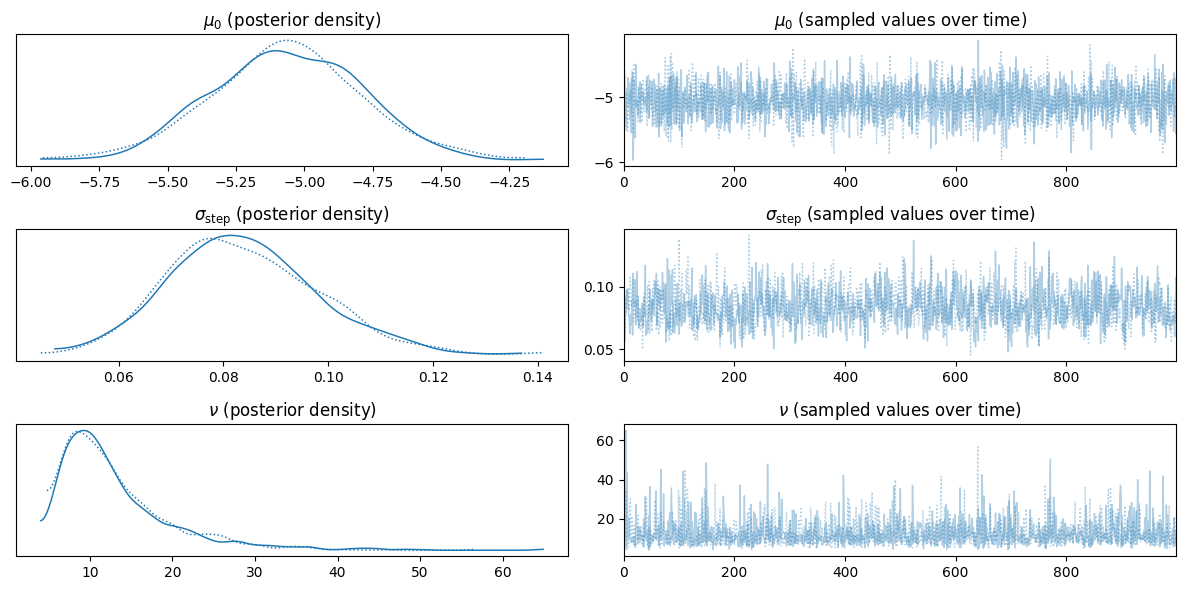

In [ ]:
axes = az.plot_trace(idata, var_names=["mu0", "step_size", "nu"])
axes[0, 0].set_title(r"$\mu_0$ (posterior density)")
axes[0, 1].set_title(r"$\mu_0$ (sampled values over time)")
axes[1, 0].set_title(r"$\sigma_{\mathrm{step}}$ (posterior density)")
axes[1, 1].set_title(r"$\sigma_{\mathrm{step}}$ (sampled values over time)")
axes[2, 0].set_title(r"$\nu$ (posterior density)")
axes[2, 1].set_title(r"$\nu$ (sampled values over time)")
plt.tight_layout()
plt.show()
# So we have a posterior plot just like these for every single day.

# What changed in the posterior shapes themselves?

Beyond just converging better, the shape of $σ_{step}$'s posterior is worth noticing directly: it's visibly right-skewed — a sharper rise up to its peak around 0.08, then a longer, gradually thinning tail out toward 0.13–0.14, rather than a symmetric bell shape. This makes sense given $σ_{step}$ is a HalfNormal-constrained scale parameter (it can never be negative), so its distribution is naturally bounded on one side and free to stretch further on the other. Both chains (solid and dotted lines) land almost exactly on top of each other across all three posterior density plots — $μ_0$, $σ_{step}$, and ν — which is the visual signature of good convergence: two independently-started explorations of the same landscape arriving at the same conclusion about its shape, rather than disagreeing (as $σ_{step}$ visibly did in Part 3).

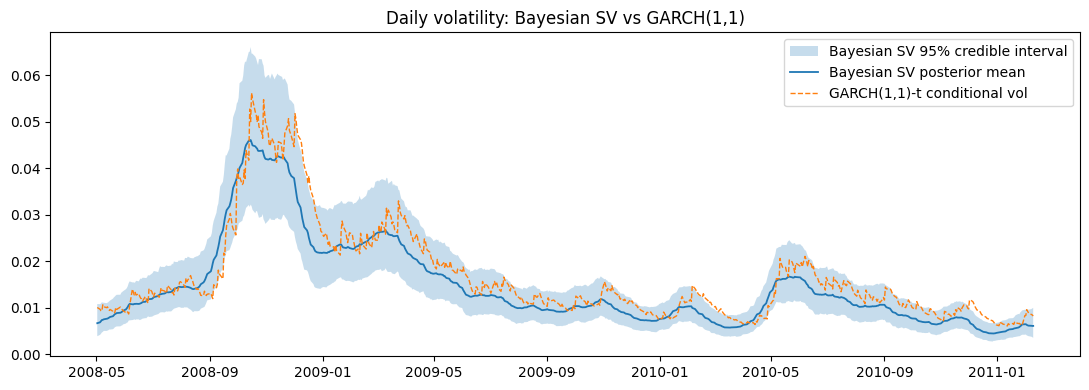

In [ ]:
# For each posterior draw, exp(h_t) is that draw's implied daily volatility
# at time t. Averaging exp(h_t) across all ~2,000 draws gives the posterior
# mean path; the 2.5th/97.5th percentiles across draws give the 95%
# credible interval. This is plotted directly against GARCH's conditional
# volatility from Part 2 (same 700-day crisis window, for a fair comparison).

h_post = idata.posterior["h"]
vol_post = np.exp(h_post)
vol_mean = vol_post.mean(dim=["chain", "draw"]).values
vol_lo = vol_post.quantile(0.025, dim=["chain", "draw"]).values
vol_hi = vol_post.quantile(0.975, dim=["chain", "draw"]).values

fig, ax = plt.subplots(figsize=(11, 4))
ax.fill_between(crisis.index, vol_lo, vol_hi, alpha=0.25,
                 label="Bayesian SV 95% credible interval")
ax.plot(crisis.index, vol_mean, lw=1.3, label="Bayesian SV posterior mean")
ax.plot(crisis.index, cond_vol_crisis, ls="--", lw=1.0, label="GARCH(1,1)-t conditional vol")
ax.legend()
ax.set_title("Daily volatility: Bayesian SV vs GARCH(1,1)")
plt.tight_layout()
plt.show()

# Comparing to GARCH

Plotting the recovered volatility path against GARCH's (Part 2) shows both methods largely agreeing on the overall shape of the crisis — a sharp rise through September–October 2008, peaking near 4.5–4.8% daily, then a gradual decay through 2009, with a smaller secondary spike around mid-2010. Two completely different estimation philosophies — one maximum likelihood, one MCMC — arriving at essentially the same story is reassuring, since neither shares the other's specific assumptions or failure modes.

The real difference is what the Bayesian version adds on top: a genuine credible interval, not just a line. Where GARCH gives one number for tomorrow's volatility with no attached sense of how sure that number actually is, the Bayesian posterior shows this directly — the band visibly narrows during calm stretches (the 2,000 draws largely agree) and widens sharply during the most chaotic days of the crisis (the draws genuinely disagree more), which is exactly the kind of honest "here's how confident I actually am" signal a single point estimate can never provide.

# Where this goes next

Having a full posterior — not just a point estimate — for the entire volatility path opens up several things a single-number model can't do at all: turning an ambiguous statistical test into a direct, decision-usable probability (explored in the VaR section later), formally testing whether modeling choices like fat tails actually matter rather than just assuming they do (the model comparison in the next section), and — as discussed earlier — using every individual posterior draw's own parameters to generate a genuine distribution of forecasts for a future day, rather than collapsing to one predicted number the way a naive forecast would.

# Part 5: t-distribution check

Every model so far in this notebook has assumed returns follow a t-distribution rather than a plain Normal one, on the reasoning that real market returns produce extreme moves far more often than a Normal distribution would predict — the "fat tails" idea discussed earlier. That's a reasonable assumption, but it's still just an assumption until it's actually tested against the alternative. This section does exactly that: fit the identical non-centered model from Part 4, but swap t-distribution for a plain Normal distribution, and formally compare the two using two separate, complementary checks.

Check 1 — LOO (Leave-One-Out cross-validation): which model predicts unseen data better? The question LOO tries to answer is: "if this one specific day had been left out when fitting the model, how well would the model still predict it?" This is a meaningfully harder, more honest test than just checking how well a model fits data it already saw — a model can always be made to fit its own training data well by being flexible enough; predicting a day it wasn't shown is a much fairer test of whether it actually learned something real. Doing this literally would mean refitting the model 700 separate times, once per omitted day — far too expensive here. PSIS-LOO is a statistical shortcut that approximates this same answer directly from the posterior draws already collected, without needing to refit anything. It produces a number called elpd (expected log predictive density) for each model — higher is better — along with an elpd_diff (how much worse the second-place model scored) and a dse (the uncertainty on that difference itself). If dse is as large as or larger than elpd_diff, the apparent difference between the two models could easily just be noise rather than a genuine, meaningful gap.

Check 2 — Posterior predictive checks: does the model actually produce realistic-looking data? This asks a different, complementary question: take the fitted model, use it to generate entirely fake, simulated return data, and check whether that simulated data statistically resembles the real thing. Kurtosis is the specific statistic used here — it measures how fat-tailed a distribution is, with higher values meaning more frequent extreme events than a Normal distribution would produce. Comparing the real data's kurtosis against the kurtosis of many simulated datasets tells you whether the model's assumptions genuinely match reality, rather than just checking whether its parameters converged nicely.

The results

LOO comparison:

In [ ]:
# Fit the identical non-centered model from Part 4, but with Normal return
# innovations instead of the t-distribution, then compare the two via PSIS-LOO to
# test whether the fat-tails assumption is actually earning its keep.

with pm.Model(coords={"time": crisis.index.values}) as sv_normal:
    mu0_n = pm.Normal("mu0", -9.0, 1.0)
    step_size_n = pm.HalfNormal("step_size", 0.15)
    z_n = pm.Normal("z", 0, 1, dims="time")
    h_n = pm.Deterministic("h", mu0_n + step_size_n * pm.math.cumsum(z_n), dims="time")
    r_n = pm.Normal("r", mu=0, sigma=pm.math.exp(h_n), observed=crisis.values, dims="time")
    idata_normal = pm.sample(1000, tune=1000, chains=2, target_accept=0.92, random_seed=42)
    pm.compute_log_likelihood(idata_normal)

# Also needed from the t-distribution model (Part 4) for the comparison below:
with sv_nc:
    pm.compute_log_likelihood(idata)

az.compare({"t-distribution innovations": idata, "Normal innovations": idata_normal})

Computing ... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00

/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
t-distribution innovations,0,2001.013836,37.211951,0.000000,0.72236,26.311321,0.000000,False,log
Normal innovations,1,2000.147768,43.996178,0.866068,0.27764,25.837846,1.974177,True,log


The t-distribution comes out ahead, but only barely — elpd_diff = 0.87 is smaller than its own uncertainty (dse = 1.97), which means this difference can't be called decisive. At this sample size (700 days), the data leans toward fat tails mattering, but doesn't conclusively prove it. What tips the read slightly further in the t-distributions favor is the Pareto-k warning, which appeared only on the Normal model: this warning fires when the statistical approximation LOO relies on starts to break down, which typically happens when a handful of data points are unusually influential — here, that's almost certainly a few genuinely extreme crisis-era return days that a Normal distribution simply isn't built to explain well, while the t-distribution can accommodate them more naturally.

In [23]:
with sv_nc:
    ppc = pm.sample_posterior_predictive(idata, var_names=["r"], random_seed=42)

Output()

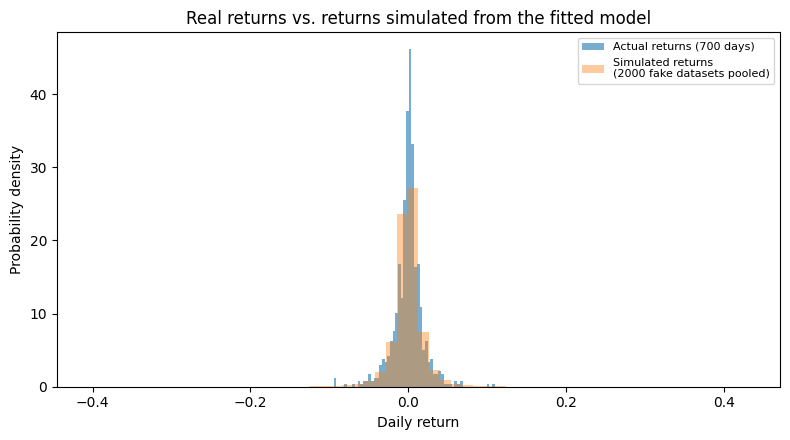

Actual excess kurtosis: 5.99
Posterior predictive excess kurtosis, mean over simulated datasets: 9.71


In [24]:
# Does simulated data from the fitted model actually resemble real returns?
# Simulate many fake 700-day datasets (one per posterior draw, using that
# draw's own h path and nu), pool them together, and compare their shape
# directly against the real data.

ppc_draws = ppc.posterior_predictive["r"].values.reshape(-1, len(crisis))
actual_kurt = stats.kurtosis(crisis.values)
ppc_kurt = np.array([stats.kurtosis(row) for row in ppc_draws[:500]])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(crisis.values, bins=60, density=True, alpha=0.6, label="Actual returns (700 days)")
ax.hist(ppc_draws.flatten(), bins=60, density=True, alpha=0.4,
        label=f"Simulated returns\n({ppc_draws.shape[0]} fake datasets pooled)")
ax.set_xlabel("Daily return")
ax.set_ylabel("Probability density")
ax.set_title("Real returns vs. returns simulated from the fitted model")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"Actual excess kurtosis: {actual_kurt:.2f}")
print(f"Posterior predictive excess kurtosis, mean over simulated datasets: {ppc_kurt.mean():.2f}")

Posterior predictive check: simulating fake return data from the fitted model and overlaying it against the real returns (above) shows a similar overall shape — both concentrated tightly around zero with a spread of more extreme values further out. As a numerical check on this, the real data's excess kurtosis is 5.99, while the average excess kurtosis across many simulated datasets comes out to 9.71 — somewhat higher, driven by a subset of posterior draws with an unusually small ν producing occasional very extreme simulated values. This is consistent with the LOO finding above: fat tails are a reasonable assumption here, though the exact degree of tail-fatness carries genuine uncertainty rather than being pinned down precisely by 700 days of data.

I am now going to check if the data actually seems to be adding worthwhile information. Extension prompted by LinkedIn commenter (Ashraf SAID : https://www.linkedin.com/in/saidashraf/)

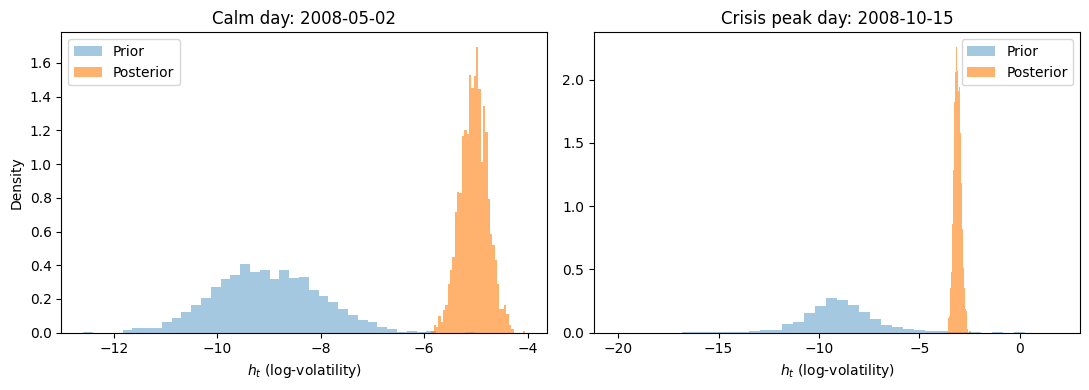

In [25]:
with sv_nc:
    prior = pm.sample_prior_predictive(samples=2000, var_names=["h"], random_seed=42)

h_prior = prior.prior["h"]  # same shape convention as h_post: (chain, draw, time)

day_calm = 0
day_crisis = crisis.index.get_loc(crisis.loc["2008-09-15":"2008-10-15"].index[
    np.exp(h_post.isel(time=slice(None))).mean(dim=["chain","draw"]).sel(
        time=slice("2008-09-15","2008-10-15")).argmax().item()
])

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, day, label in zip(axes, [day_calm, day_crisis], ["Calm day", "Crisis peak day"]):
    prior_vals = h_prior.isel(time=day).values.flatten()
    post_vals  = h_post.isel(time=day).values.flatten()
    ax.hist(prior_vals, bins=40, density=True, alpha=0.4, label="Prior")
    ax.hist(post_vals, bins=40, density=True, alpha=0.6, label="Posterior")
    ax.set_title(f"{label}: {crisis.index[day].date()}")
    ax.set_xlabel(r"$h_t$ (log-volatility)")
    axes[0].set_ylabel("Density")
    ax.legend()

plt.tight_layout()
plt.show()

Both days show a clear shift from prior to posterior, and the posterior is
noticeably tighter than the prior in each case — indicating the data is
adding real information, not just reflecting the smoothness of the random-walk
prior. Interestingly, the crisis-day posterior is even tighter than the calm
day's, which may suggest that large-magnitude returns are more informative
about volatility than small ones — though this is based on just two days and
would need checking across more of the sample to say with confidence.

# Part 6


"How confident are we that volatility during the worst of the crisis (say, October 2008) was actually higher than during the second, smaller spike (say, May 2010)?"

In [26]:
# A SIMPLER APPLICATION: comparing two specific days using the posterior
# Reuses vol_post from Part 4 directly -- no new calculation needed.
# For EACH of the ~2000 posterior draws, just check: was that draw's guess
# at October 2008's volatility bigger than its guess at May 2010's? Then see
# what fraction of the ~2000 draws answered "yes."

day_a = "2008-10-15"  # near the crisis peak
day_b = "2010-03-20"  # near the smaller secondary spike

vol_a = vol_post.sel(time=day_a, method="nearest")   # one column: ~2000 draws' guesses for this one day
vol_b = vol_post.sel(time=day_b, method="nearest")   # a different column: ~2000 draws' guesses for this other day

prob_a_higher = (vol_a > vol_b).mean().item()

print(f"Volatility on {day_a}: posterior mean = {vol_a.mean().item():.2%}")
print(f"Volatility on {day_b}: posterior mean = {vol_b.mean().item():.2%}")
print(f"P(volatility was higher on {day_a} than {day_b}): {prob_a_higher:.2%}")

Volatility on 2008-10-15: posterior mean = 4.61%
Volatility on 2010-03-20: posterior mean = 0.58%
P(volatility was higher on 2008-10-15 than 2010-03-20): 100.00%


"What's the probability the market was in a high-volatility regime, on any given day?"

Rather than comparing day A to day B, pick one fixed volatility level — say, 2% daily — and ask, for every one of the 700 days: "what fraction of the ~2,000 posterior draws think volatility exceeded 2% on this day?" Do this separately for all 700 days, and you get a genuine time series of probabilities — not a probability that something happened once, but a full curve showing how the model's confidence about "is this a crisis day" evolved day by day through the whole window.

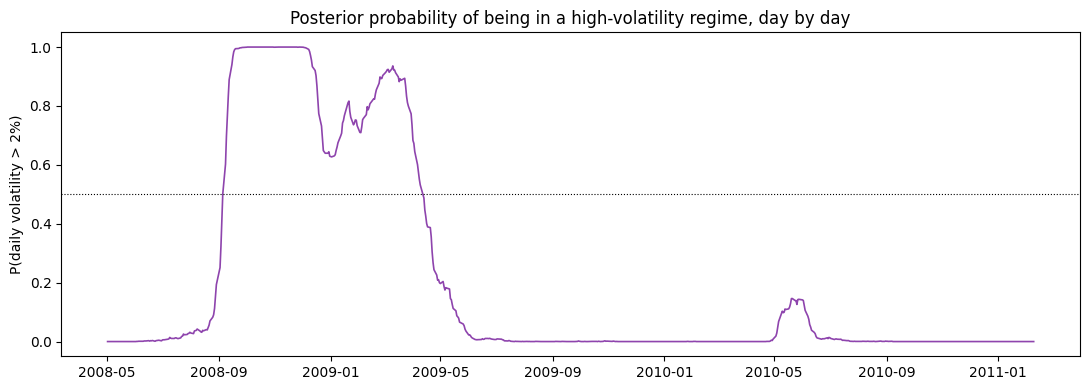

In [27]:
# EXTENSION: Probability of a "high-volatility regime," for every day
# For EACH day (each column of vol_post), compute what fraction of the
# ~2000 posterior draws think that day's volatility exceeded a fixed
# threshold. This turns the single pairwise comparison above into a full
# day-by-day probability curve -- the same underlying mechanism, applied
# across all 700 columns instead of just two.

threshold = 0.02   # 2% daily volatility -- roughly the GARCH baseline's "calm market" ceiling

prob_high_vol = (vol_post > threshold).mean(dim=["chain", "draw"])  # one probability per day

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(crisis.index, prob_high_vol, color="#8e44ad", lw=1.2)
ax.axhline(0.5, color="black", ls=":", lw=0.8)
ax.set_ylabel(f"P(daily volatility > {threshold:.0%})")
ax.set_title("Posterior probability of being in a high-volatility regime, day by day")
plt.tight_layout()
plt.show()

Creating VaR plot

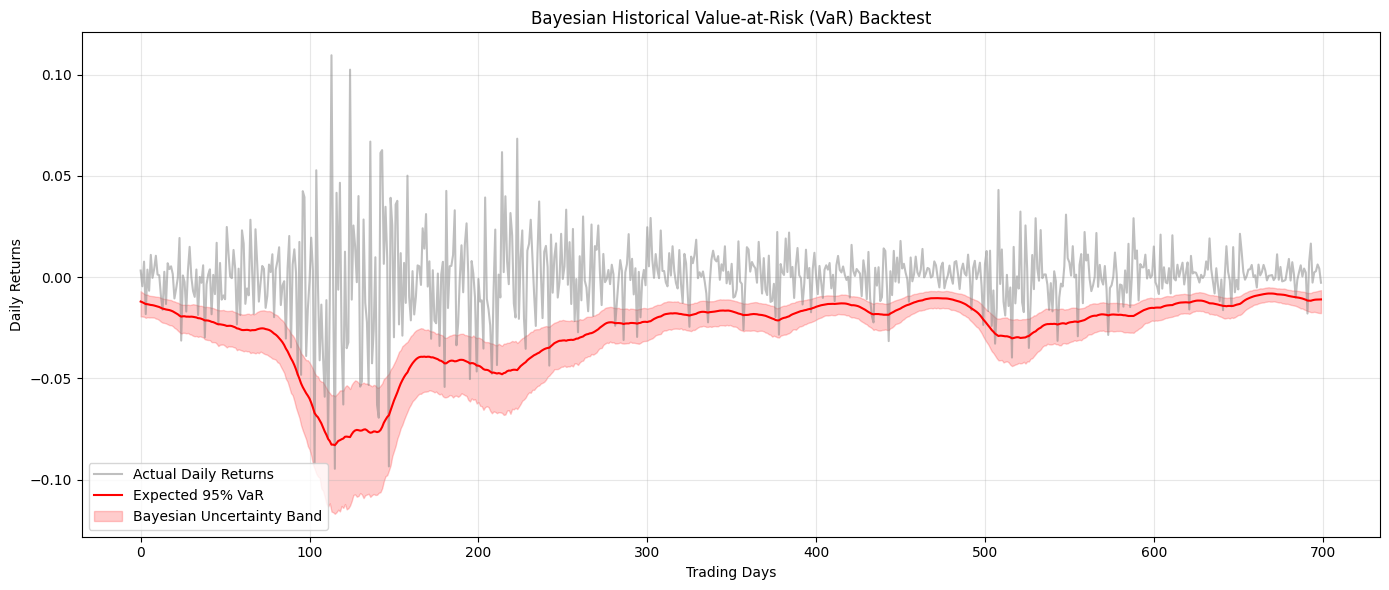

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# STEP 0: STAND-ALONE SETUP
# NOTE: To use your actual project data, delete this Step 0 block and use:
# returns = crisis.values
# nu_samples = idata.posterior["nu"].values.flatten()[:, None]
# h_samples = idata.posterior["h"].values.reshape(2000, len(returns))

days = 700
universes = 2000

returns = crisis.values

# Extract your actual MCMC posteriors from the idata object!
nu_samples = idata.posterior["nu"].values.flatten()[:, None]

# Extract 'h', and reshape it to (2000 universes, 700 days)
h_raw = idata.posterior["h"].values
chains, draws, days = h_raw.shape
h_samples = h_raw.reshape(chains * draws, days)
# STEP 1: Convert Log-Volatility to Standard Deviation
# Convert the latent volatility (h) to standard deviation (sigma)
sigma_samples = np.exp(h_samples)

# STEP 2: Calculate VaR for every universe, every day
# We use the mathematical lookup (ppf) to find the 5% cutoff instantly.
# This calculates 1.4 million VaR points at once! (2000 universes x 700 days)
var_95_all = stats.t.ppf(0.05, df=nu_samples, loc=0, scale=sigma_samples)
# Uses the generated parameter values used in the posterior and then calculated 2000 VaR values from the t distribution.
 # (Percent Point Function): This is what we are using for the backtest. It does not generate returns ($r$).
 # Instead, it uses the mathematical blueprint of the T-distribution to calculate exactly where the 5% cutoff line (VaR) is.

# STEP 3: Collapse universes into daily expected values & bands
# Average across the 2,000 universes for each individual day
expected_var = np.mean(var_95_all, axis=0)

# Extract the 95% confidence interval for the uncertainty band
lower_var_bound = np.percentile(var_95_all, 2.5, axis=0)
upper_var_bound = np.percentile(var_95_all, 97.5, axis=0)

# STEP 4: Plot the Backtest
plt.figure(figsize=(14, 6))

# 1. Plot the actual daily returns of the asset
plt.plot(returns, color='gray', alpha=0.5, label='Actual Daily Returns')

# 2. Plot the Expected 95% VaR
plt.plot(expected_var, color='red', linewidth=1.5, label='Expected 95% VaR')

# 3. Shade the Bayesian Uncertainty Band
plt.fill_between(
    range(days),
    lower_var_bound,
    upper_var_bound,
    color='red',
    alpha=0.2,
    label='Bayesian Uncertainty Band'
)

# Formatting
plt.title("Bayesian Historical Value-at-Risk (VaR) Backtest")
plt.xlabel("Trading Days")
plt.ylabel("Daily Returns")
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Clarification on Bayesian approach

## Estimating the Past (In-Sample Smoothing)

When we plot the daily volatility for the 700 days in our dataset, we are performing Estimation (specifically, "smoothing").

The model already holds the answer key—the actual observed returns for all 700 days. To figure out the volatility on Day 15, the model requires the actual return data from Day 15. It proposes a guess for the volatility, and then uses the Day 15 return data to "grade" that guess via the Likelihood function.

The beautiful, tight 95% credible intervals you see on the plot exist precisely because the model is anchored by the reality of the observed data. It is not a prediction; it is a highly educated, reverse-engineered map of what must have happened.

## Forecasting the Future (Out-of-Sample Prediction)

What happens if we want to know the volatility for Day 701 (tomorrow)?

We do not have the actual return data for Day 701, so the Likelihood function cannot grade our guesses. Instead, we must rely purely on the model's structural rules—specifically, the random walk:

$h_{701} \sim \text{Normal}(h_{700}, \sigma_{\text{step}}^2)$

To forecast Day 701, the model takes its best guess for Day 700 and takes a blind, random step forward based on the step size ($\sigma_{\text{step}}$). Because there is no data to tell the model if that step was good or bad, it must accept all of them.

If you attempt to forecast 5 or 10 days into the future, you will see the 95% credible interval explode into a massive fan shape. Without the anchor of observed data, the model's uncertainty compounds with every blind step it takes.

Summary: The plots in this project demonstrate the model's power to explain the past and map hidden risk regimes rather than future data.

**Extension: Suggested by a LinkedIn commenter (Peter Cotton : https://www.linkedin.com/in/petercotton/) online calibration once forecasting is added.** The smoothing vs.
forecasting distinction above also determines when self-calibration techniques
become meaningful. Methods like PIT-based homogenization (pushing each realized
value through the model's own *previously issued* predictive CDF, then correcting
the distribution's width based on the resulting calibration) are a natural fit
for one-step-ahead forecasting, since they depend on each prediction genuinely
preceding its outcome. They aren't meaningfully applicable to the current model,
since `h_t` is estimated using day `t`'s own return as part of the joint fit —
grading the model this way would mostly reflect how well it describes data it
already saw, not real forecasting skill. Worth revisiting once the model is
extended to true out-of-sample prediction.

**Extension: a Bayesian EGARCH model.** A LinkedIn commenter (Steve Jewson : https://www.linkedin.com/in/steve-jewson-phd-052bb417/) suggested a
GARCH-type model built directly on log-volatility, pointing out the same
statistical and numerical advantages that motivated the non-centered
reparameterization in Part 4. Testing this: an EGARCH(1,1)-t model was fit
alongside the plain GARCH(1,1)-t baseline from Part 2, on the same data.
EGARCH won decisively on both information criteria (AIC 7387.8 vs. 7553.8;
BIC 7423.6 vs. 7577.7), and its leverage term (gamma = -0.197, p ~ 2.5e-05)
confirmed a genuine asymmetric effect: negative returns raise volatility more
than positive returns of the same size, something plain GARCH cannot express
at all.

This result is a second, independent piece of evidence for the same
underlying principle behind Part 4's fix: parameterizing in log-volatility
space removes the positivity constraints that create awkward geometry for an
optimizer or sampler to navigate. Part 4 demonstrated this for MCMC; the
EGARCH result demonstrates it independently for classical maximum-likelihood
estimation. Two unrelated model families, two different fitting methods, the
same reparameterization trick paying off in both.

**A natural next step: combine the two.** The current Bayesian SV model is
*parameter-driven* — `h_t` is its own hidden random process, with an
independent noise term `z_t` on every single day, only loosely tied to
returns through the likelihood. EGARCH is *observation-driven* — volatility
is a deterministic recursive formula built directly from past returns, with
no separate day-by-day latent noise at all.

A Bayesian EGARCH would keep EGARCH's deterministic recursion (built with
`pytensor.scan`) but put priors directly on its handful of parameters
(`omega, alpha, gamma, beta, nu`) and fit them via MCMC instead of MLE. This
removes the day-by-day randomness in the volatility path itself — given the
parameters, the path is fully determined — but keeps genuine uncertainty
about what those parameters are, expressed as a full posterior rather than a
point estimate with a standard error. Practically, this would mean:

- Only 5 parameters to sample, versus ~700+ in the current model (one `z_t`
  per day plus `mu0` and `step_size`) — a dramatically smaller, better-behaved
  parameter space, with essentially no funnel risk since there's no
  high-dimensional latent path to navigate.
- A full credible interval directly on the leverage effect (`gamma`), instead
  of just a p-value from the classical fit above — a natural fit for the same
  kind of probability statements Part 6 already makes elsewhere in this
  project.
- A real trade-off, not a strict upgrade: the current SV model's extra
  flexibility — volatility can move for reasons beyond what past returns
  mechanically dictate — is genuinely lost. Parameter-driven SV models are
  generally considered more expressive for exactly this reason. Which
  structure is preferable depends on whether that extra flexibility is worth
  its computational and interpretive cost for the question being asked.

# Part 7 - EGARCH- Classical Baseline

Motivated by Steve Jewson : https://www.linkedin.com/in/steve-jewson-phd-052bb417/

The method and motivation is described in the Extension 2, just above.

In [29]:
# Fit EGARCH(1,1)-t as an alternative to Part 2's plain GARCH baseline,
# to test the log-volatility structure suggested by a LinkedIn commenter.
# Same interface as Part 2, just vol="EGARCH" with an added leverage term (o=1).

am_egarch = arch_model(returns_pct, mean="Constant", vol="EGARCH", p=1, o=1, q=1, dist="t")
res_egarch = am_egarch.fit(disp="off")
print(res_egarch.summary())

print("\nGARCH  AIC/BIC:", round(res_full.aic, 1), round(res_full.bic, 1))
print("EGARCH AIC/BIC:", round(res_egarch.aic, 1), round(res_egarch.bic, 1))

                        Constant Mean - EGARCH Model Results                        
Dep. Variable:                       change   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                           EGARCH   Log-Likelihood:               -3687.88
Distribution:      Standardized Student's t   AIC:                           7387.77
Method:                  Maximum Likelihood   BIC:                           7423.61
                                              No. Observations:                 2906
Date:                      Mon, Aug 17 2026   Df Residuals:                     2905
Time:                              00:21:15   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             0

EGARCH function

In [30]:
E_abs_z = np.sqrt(2 / np.pi)

def step(r_prev, log_sigma2_prev, omega, alpha, gamma, beta):
    sigma_prev = np.sqrt(np.exp(log_sigma2_prev))
    z_prev = r_prev / sigma_prev
    todays_log_variance = omega + alpha * (np.abs(z_prev) - E_abs_z) + gamma * z_prev + beta * log_sigma2_prev
    return todays_log_variance

Example of the EGARCH modelled on just the crisis window.

In [31]:
am_egarch_crisis = arch_model(crisis_pct, mean="Constant", vol="EGARCH", p=1, o=1, q=1, dist="t")
res_egarch_crisis = am_egarch_crisis.fit(disp="off")
print(res_egarch_crisis.summary())

                        Constant Mean - EGARCH Model Results                        
Dep. Variable:                       change   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                           EGARCH   Log-Likelihood:               -1216.74
Distribution:      Standardized Student's t   AIC:                           2445.47
Method:                  Maximum Likelihood   BIC:                           2472.78
                                              No. Observations:                  700
Date:                      Mon, Aug 17 2026   Df Residuals:                      699
Time:                              00:21:20   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu        

Applying the Bayesian method with the EGARCH output (step function).

In [36]:
!pip install -q numpyro

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.8/394.8 kB 12.9 MB/s eta 0:00:00


In [37]:
from pytensor import scan
import pytensor.tensor as pt
r = crisis.values
log_sigma2_init = np.log(np.var(r))

with pm.Model() as bayes_egarch:
    omega = pm.Normal("omega", 0, 1)
    alpha = pm.Normal("alpha", 0, 0.5)
    gamma = pm.Normal("gamma", 0, 0.5)
    beta = pm.Normal("beta", 0, 0.5)
    nu = pm.Exponential("nu", 1 / 10)

    log_sigma2_seq, _ = scan(
        fn=step,
        sequences=[r[:-1]],
        outputs_info=[pt.constant(log_sigma2_init)],
        non_sequences=[omega, alpha, gamma, beta],
    )
    log_sigma2_seq = pm.Deterministic("log_sigma2", log_sigma2_seq)

    obs = pm.StudentT("r", nu=nu, mu=0, sigma=pm.math.exp(log_sigma2_seq / 2),
                       observed=crisis.values[1:])

    idata_bayes_egarch = pm.sample(1000, tune=1000, chains=2, target_accept=0.9,
                                     random_seed=42, nuts_sampler="numpyro")
az.summary(idata_bayes_egarch, var_names=["omega", "alpha", "gamma", "beta", "nu"])

/tmp/ipykernel_1241/3196972835.py:13: DeprecationWarning: Scan return signature will change. Updates dict will not be returned, only the first argument. Pass `return_updates=False` to conform to the new API and avoid this warning
  log_sigma2_seq, _ = scan(


  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
omega,-0.235,0.063,-0.349,-0.116,0.003,0.002,500.0,560.0,1.0
alpha,0.140,0.031,0.086,0.199,0.001,0.001,978.0,767.0,1.0
gamma,-0.149,0.028,-0.204,-0.100,0.001,0.001,807.0,1043.0,1.0
beta,0.974,0.007,0.961,0.987,0.000,0.000,475.0,585.0,1.0
nu,9.282,4.156,4.052,15.787,0.178,0.340,1022.0,523.0,1.0


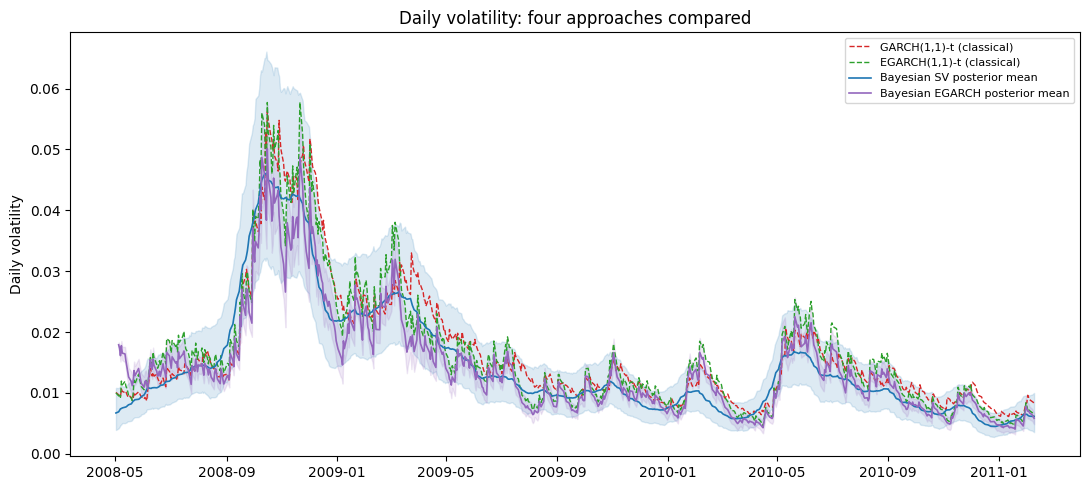

In [38]:
vol_bayes_egarch = np.exp(idata_bayes_egarch.posterior["log_sigma2"] / 2)
vol_bayes_egarch_mean = vol_bayes_egarch.mean(dim=["chain", "draw"])
vol_bayes_egarch_lower = vol_bayes_egarch.quantile(0.025, dim=["chain", "draw"])
vol_bayes_egarch_upper = vol_bayes_egarch.quantile(0.975, dim=["chain", "draw"])

vol_post_mean = np.exp(h_post).mean(dim=["chain", "draw"])
vol_post_lower = np.exp(h_post).quantile(0.025, dim=["chain", "draw"])
vol_post_upper = np.exp(h_post).quantile(0.975, dim=["chain", "draw"])

dates_egarch = crisis.index[1:]  # 699 dates — Bayesian EGARCH predicts day t using day t-1

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(crisis.index, cond_vol_crisis, "--", color="tab:red", lw=1, label="GARCH(1,1)-t (classical)")
ax.plot(crisis.index, res_egarch_crisis.conditional_volatility / 100, "--", color="tab:green", lw=1, label="EGARCH(1,1)-t (classical)")
ax.plot(crisis.index, vol_post_mean, color="tab:blue", lw=1.2, label="Bayesian SV posterior mean")
ax.fill_between(crisis.index, vol_post_lower, vol_post_upper, color="tab:blue", alpha=0.15)
ax.plot(dates_egarch, vol_bayes_egarch_mean, color="tab:purple", lw=1.2, label="Bayesian EGARCH posterior mean")
ax.fill_between(dates_egarch, vol_bayes_egarch_lower, vol_bayes_egarch_upper, color="tab:purple", alpha=0.15)

ax.set_title("Daily volatility: four approaches compared")
ax.set_ylabel("Daily volatility")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

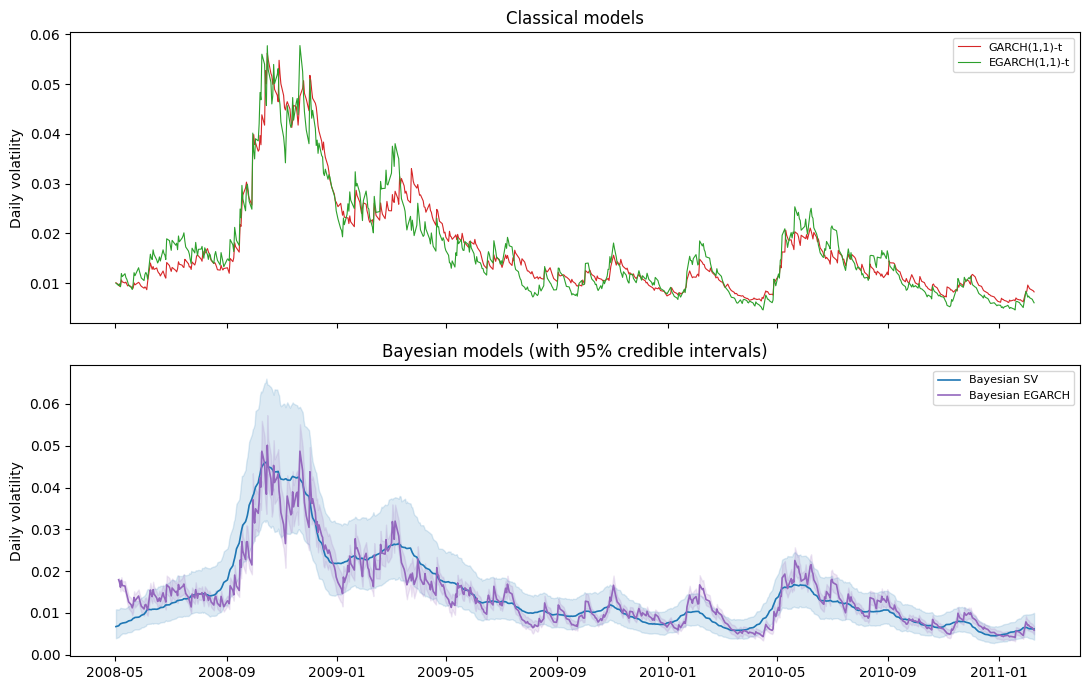

In [39]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

ax1.plot(crisis.index, cond_vol_crisis, color="tab:red", lw=0.8, label="GARCH(1,1)-t")
ax1.plot(crisis.index, res_egarch_crisis.conditional_volatility / 100, color="tab:green", lw=0.8, label="EGARCH(1,1)-t")
ax1.set_title("Classical models")
ax1.legend(fontsize=8)
ax1.set_ylabel("Daily volatility")

ax2.plot(crisis.index, vol_post_mean, color="tab:blue", lw=1.2, label="Bayesian SV")
ax2.fill_between(crisis.index, vol_post_lower, vol_post_upper, color="tab:blue", alpha=0.15)
ax2.plot(dates_egarch, vol_bayes_egarch_mean, color="tab:purple", lw=1.2, label="Bayesian EGARCH")
ax2.fill_between(dates_egarch, vol_bayes_egarch_lower, vol_bayes_egarch_upper, color="tab:purple", alpha=0.15)
ax2.set_title("Bayesian models (with 95% credible intervals)")
ax2.legend(fontsize=8)
ax2.set_ylabel("Daily volatility")

plt.tight_layout()
plt.show()

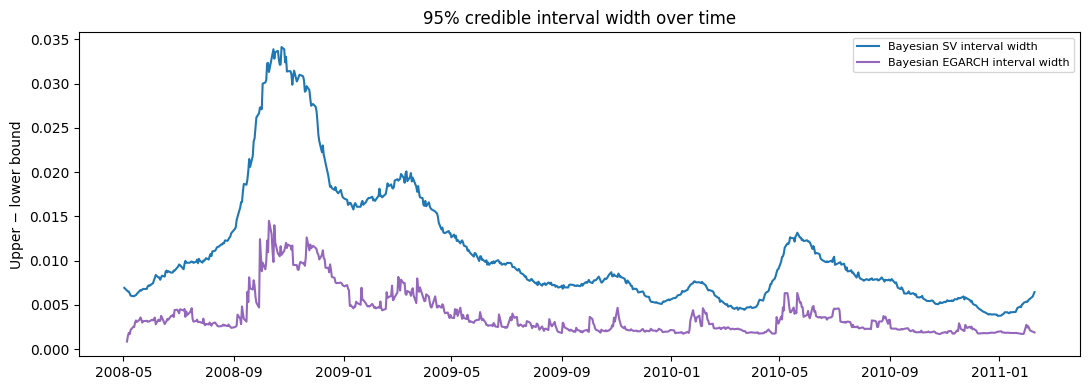

In [40]:
width_sv = vol_post_upper - vol_post_lower
width_egarch = vol_bayes_egarch_upper - vol_bayes_egarch_lower

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(crisis.index, width_sv, color="tab:blue", label="Bayesian SV interval width")
ax.plot(dates_egarch, width_egarch, color="tab:purple", label="Bayesian EGARCH interval width")
ax.set_title("95% credible interval width over time")
ax.set_ylabel("Upper − lower bound")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

Comparing the two Bayesian models: PSIS-LOO

Visually, Bayesian EGARCH's credible intervals are noticeably tighter than Bayesian SV's throughout the crisis window. Interval width alone doesn't tell you which model is actually better, though — a model can produce artificially narrow intervals simply by being overconfident, which would make it worse, not better, even though it looks tidier on a plot. The real test is whether each model's uncertainty is calibrated: does it predict held-out data well, not just describe the data it already saw.

Both models were refit on identical data (the same 699 days) and compared via PSIS-LOO cross-validation, the same technique used in Part 5 to test Student-t against Normal innovations.

In [41]:
# Refit the SV model on 699 days (dropping day 0), so both models are
# scored on identical observed data for a fair PSIS-LOO comparison.

crisis_699 = crisis.values[1:]
dates_699 = crisis.index[1:]

with pm.Model(coords={"time": dates_699}) as sv_nc_699:
    mu0 = pm.Normal("mu0", -9.0, 1.0)
    step_size = pm.HalfNormal("step_size", 0.15)
    z = pm.Normal("z", 0, 1, dims="time")
    h = pm.Deterministic("h", mu0 + step_size * pm.math.cumsum(z), dims="time")
    nu = pm.Exponential("nu", 1 / 10)
    r = pm.StudentT("r", nu=nu, mu=0, sigma=pm.math.exp(h),
                     observed=crisis_699, dims="time")

    idata_sv_699 = pm.sample(1000, tune=1000, chains=2, target_accept=0.92,
                               random_seed=42, nuts_sampler="numpyro")
    pm.compute_log_likelihood(idata_sv_699)

az.summary(idata_sv_699, var_names=["mu0", "step_size", "nu"])

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

Output()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu0,-4.989,0.251,-5.452,-4.528,0.005,0.005,2158.0,1534.0,1.0
step_size,0.083,0.013,0.058,0.107,0.000,0.000,834.0,1131.0,1.0
nu,13.066,7.243,4.391,25.422,0.192,0.358,1980.0,1244.0,1.0


In [42]:
with bayes_egarch:
    pm.compute_log_likelihood(idata_bayes_egarch)

Output()

                 rank     elpd_loo      p_loo  elpd_diff    weight         se  \
Bayesian SV         0  1997.639384  36.548940   0.000000  0.588905  26.221641   
Bayesian EGARCH     1  1992.106178   5.096665   5.533206  0.411095  26.274857   

                     dse  warning scale  
Bayesian SV      0.00000    False   log  
Bayesian EGARCH  7.69597    False   log  


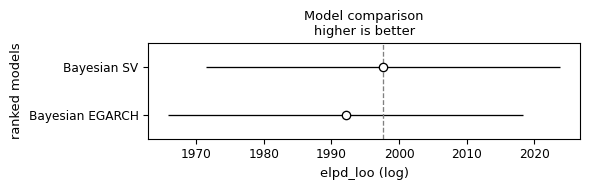

In [43]:
comparison = az.compare({"Bayesian SV": idata_sv_699, "Bayesian EGARCH": idata_bayes_egarch})
print(comparison)

az.plot_compare(comparison)
plt.tight_layout()
plt.show()

elpd_diff (5.53) is smaller than its own uncertainty (dse = 7.70), the same pattern found for t vs. Normal in Part 5. This means the two models predict held-out days about equally well — the difference is not statistically decisive, and Bayesian SV's marginally higher rank shouldn't be read as a meaningful win.

p_loo, however, is genuinely informative here. This roughly measures each model's effective number of parameters, and it lines up exactly with each model's structure: Bayesian SV has ~700 flexible daily z_t values it can draw on, giving it a p_loo of 36.5, while Bayesian EGARCH has only 5 fixed parameters total, giving it a p_loo of 5.1. Neither model raised a PSIS-LOO reliability warning, so both estimates can be taken at face value.

Conclusion: the two models predict equally well, but Bayesian EGARCH reaches that same predictive performance using roughly 7x fewer effective parameters. This is Occam's razor made quantitative — when two models predict similarly, the simpler one is generally preferable, since the extra flexibility in the more complex model isn't actually buying better predictions. It also explains the visual difference in interval width from the plot above: EGARCH's tighter intervals aren't overconfidence, they're the natural consequence of a model that matches SV's predictive accuracy without needing anywhere near as much flexibility to do it.

# Part 9: One-Step-Ahead Forecasting

**Suggested by a LinkedIn commenter (Peter Cotton: https://www.linkedin.com/in/petercotton/).** Everything up to this point — the SV model, the Bayesian EGARCH comparison, the PSIS-LOO check — is *in-sample smoothing*: every `h_t` or `log_sigma2_t` is estimated using that same day's own return. Peter's homogenization/PIT-calibration suggestion earlier in this notebook couldn't be meaningfully applied for exactly that reason, since it depends on each prediction genuinely preceding its outcome.

This section builds that missing piece: genuine one-step-ahead forecasting using the already-fitted Bayesian EGARCH model, tested on 200 trading days immediately following the training window (2011-02-10 to 2011-11-23) that the model has never seen. Bayesian EGARCH, not the SV model, is the natural candidate here — its recursive structure (today's volatility as a function of yesterday's return and yesterday's volatility) is inherently forward-looking, whereas the SV model has no mechanism to project `h_t` forward without inventing a new, unobserved `z_t` for a day it hasn't seen.

**Method:** walk forward day by day through the test period, using only the already-fitted posterior-mean parameters (`omega, alpha, gamma, beta, nu`) and each day's *actual preceding* return to forecast that day's volatility — never looking ahead. Forecast quality is then scored three ways: log-likelihood of the actual returns under the forecasted distribution, benchmarked against both a naive persistence forecast (yesterday's absolute return) and a fairer 20-day rolling-average benchmark; and a PIT histogram to finally test Peter's calibration idea on genuinely out-of-sample predictions.

2011-02-10 00:00:00 to 2011-11-23 00:00:00
Mean log-likelihood per day: 2.9364572993752915
Naive mean log-likelihood per day: 0.9414945663332382
Rolling-average mean log-likelihood per day: 2.8473556847010695


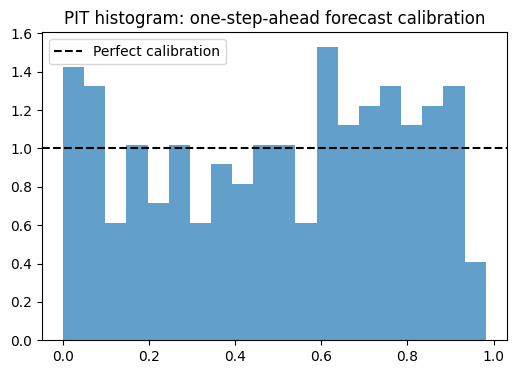

In [44]:
test_period = returns_full.iloc[700:900]  # next 200 trading days after the crisis window
print(test_period.index.min(), "to", test_period.index.max())

omega_hat = idata_bayes_egarch.posterior["omega"].mean().item()
alpha_hat = idata_bayes_egarch.posterior["alpha"].mean().item()
gamma_hat = idata_bayes_egarch.posterior["gamma"].mean().item()
beta_hat  = idata_bayes_egarch.posterior["beta"].mean().item()
nu_hat    = idata_bayes_egarch.posterior["nu"].mean().item()

log_sigma2_last = idata_bayes_egarch.posterior["log_sigma2"].mean(dim=["chain","draw"]).values[-1]

r_test = test_period.values
forecast_log_sigma2 = [log_sigma2_last]

for i in range(len(r_test)):
    r_prev = r_test[i-1] if i > 0 else crisis.values[-1]  # first forecast uses last training-day return
    new_val = step(r_prev, forecast_log_sigma2[-1], omega_hat, alpha_hat, gamma_hat, beta_hat)
    forecast_log_sigma2.append(new_val)

forecast_log_sigma2 = np.array(forecast_log_sigma2[1:])  # one forecast per test day
forecast_sigma = np.exp(forecast_log_sigma2 / 2)

log_lik = stats.t.logpdf(r_test, df=nu_hat, loc=0, scale=forecast_sigma)
print("Mean log-likelihood per day:", log_lik.mean())

naive_sigma = np.abs(np.concatenate([[crisis.values[-1]], r_test[:-1]]))
naive_log_lik = stats.t.logpdf(r_test, df=nu_hat, loc=0, scale=naive_sigma)
print("Naive mean log-likelihood per day:", naive_log_lik.mean())

window = 20

# Include `window` extra days before the test period starts, so the rolling
# average has enough history to compute a value for day 700 itself.
test_period_full_context = returns_full.iloc[700 - window : 900]

rolling_vol = test_period_full_context.rolling(window).apply(lambda x: np.abs(x).mean())

# Shift by 1 so rolling_vol[t] only uses data through t-1, never including day t itself
rolling_sigma = rolling_vol.shift(1).iloc[-len(r_test):].values

rolling_log_lik = stats.t.logpdf(r_test, df=nu_hat, loc=0, scale=rolling_sigma)
print("Rolling-average mean log-likelihood per day:", rolling_log_lik.mean())

pit_values = stats.t.cdf(r_test, df=nu_hat, loc=0, scale=forecast_sigma)

fig, ax = plt.subplots(figsize=(6,4))
ax.hist(pit_values, bins=20, density=True, alpha=0.7)
ax.axhline(1.0, color="black", ls="--", label="Perfect calibration")
ax.set_title("PIT histogram: one-step-ahead forecast calibration")
ax.legend()
plt.show()

**Is this just "predict yesterday" in disguise?** Worth asking directly, since `beta` ≈ 0.974 means today's forecast leans heavily on yesterday's volatility estimate. The naive benchmark above uses a single noisy data point (yesterday's absolute return) as its forecast, so beating it isn't strong evidence of real skill — a fairer test is a 20-day rolling average of absolute returns, which smooths out the same single-day noise without using any of EGARCH's structure.

The result: Bayesian EGARCH scores 2.94 mean log-likelihood per day, versus 2.85 for the 20-day rolling average — far closer than the 2.94-vs-0.94 gap against the naive single-day benchmark. Most of the model's forecasting advantage over *that* naive benchmark is really just "smooth out noise using recent history," which a simple rolling average achieves almost as well.

That said, this is a genuinely elegant result read the right way: EGARCH is matching a 20-day rolling average's forecast quality using only **one lagged day** plus a single decay coefficient (`beta`), rather than averaging 20 raw observations directly. It's approximating the same smoothing effect far more efficiently — exponential decay via one parameter instead of a flat 20-day window — rather than clearly outperforming it. A fair conclusion: the model captures real forecasting signal, but a meaningful share of that signal is attributable to smoothing recent history rather than to EGARCH's specific leverage/asymmetry structure.

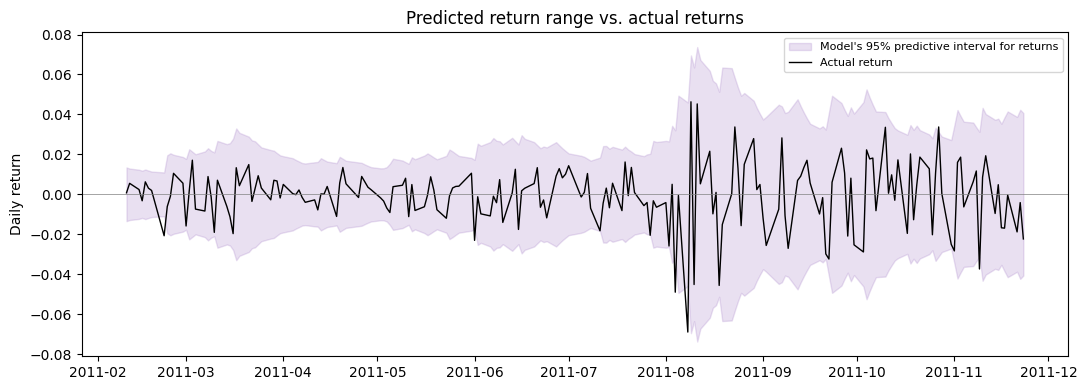

In [45]:
from scipy import stats

# 95% predictive interval for returns, using the model's own t-distribution
t_crit = stats.t.ppf(0.975, df=nu_hat)
upper_band = t_crit * forecast_sigma
lower_band = -t_crit * forecast_sigma

fig, ax = plt.subplots(figsize=(11, 4))
ax.fill_between(test_period.index, lower_band, upper_band, color="tab:purple", alpha=0.2,
                 label="Model's 95% predictive interval for returns")
ax.plot(test_period.index, r_test, color="black", lw=1, label="Actual return")
ax.axhline(0, color="gray", lw=0.5)
ax.set_title("Predicted return range vs. actual returns")
ax.set_ylabel("Daily return")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Summary.** One-step-ahead forecasts substantially outperform a naive single-day persistence benchmark on log-likelihood (2.94 vs. 0.94), confirming the model captures genuine forecasting signal rather than only describing data it has already seen. Against a fairer 20-day rolling-average benchmark (2.85), the gap narrows considerably — most of the advantage over naive persistence comes from smoothing recent history, something a simple rolling average nearly matches, though EGARCH achieves it more efficiently, using one lagged day and a decay coefficient rather than 20 raw observations.

The predicted-return-band plot above shows the model's 95% predictive interval visibly widening and narrowing with the actual volatility of returns, and the actual return staying inside the band the large majority of the time — a reasonably intuitive visual confirmation alongside the log-likelihood numbers.

The PIT histogram shows the forecasts are reasonably, but not perfectly, calibrated — actual returns land somewhat more often in the upper-middle of the predicted distribution than a perfectly calibrated model would produce. With only 200 test days, some of this deviation is expected from sample size alone, but a plausible contributing factor is that the model was fit on crisis-period dynamics and tested on the subsequent, likely calmer period — a real limitation of testing on a single, specific window, and a natural direction for further validation (e.g. testing across multiple, non-overlapping windows) rather than one fixed 200-day stretch.